# 🚴 RideAware BA2 – BERT Fine-Tuning

**Schritte:**
1. GPU aktivieren: `Laufzeit → Laufzeittyp ändern → T4 GPU`
2. Pakete installieren (Zelle 1)
3. `train_split.csv` und `test.csv` hochladen (Zelle 3)
4. Alle Zellen ausführen
5. Ergebnisse & Modell herunterladen

⏱️ Dauer mit GPU: ca. **3–5 Minuten**

## Zelle 1 – Pakete installieren

In [ ]:
!pip install transformers torch scikit-learn pandas -q
print('✅ Pakete installiert!')

✅ Pakete installiert!


## Zelle 2 – GPU prüfen

In [ ]:
import torch

if torch.cuda.is_available():
    print(f'✅ GPU verfügbar: {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
else:
    print('⚠️  Keine GPU – bitte Laufzeittyp auf T4 GPU ändern!')
    print('   Laufzeit → Laufzeittyp ändern → T4 GPU → Speichern')
    device = torch.device('cpu')

print(f'Gerät: {device}')

✅ GPU verfügbar: Tesla T4
Gerät: cuda


## Zelle 3 – Daten hochladen

Lade deine `train_split.csv` und `test.csv` hoch.

In [ ]:
import pandas as pd

df_train = pd.read_csv('train_split.csv')
df_test  = pd.read_csv('test.csv')

df_train['text']  = df_train['text'].astype(str)
df_train['label'] = df_train['label'].astype(str)
df_test['text']   = df_test['text'].astype(str)
df_test['label']  = df_test['label'].astype(str)

print(f'\n✅ Training: {len(df_train)} Beispiele')
print(f'✅ Test:     {len(df_test)} Beispiele')
print('\nKlassenverteilung Training:')
print(df_train['label'].value_counts())


✅ Training: 828 Beispiele
✅ Test:     75 Beispiele

Klassenverteilung Training:
label
Hindernis                 166
Gefahrenstelle            166
Markierung oder Schild    166
Ampel                     165
Lückenschluss             165
Name: count, dtype: int64


## Zelle 4 – Konfiguration

In [ ]:
# ── Hier kannst du die Einstellungen anpassen ──────────────────────────────

MODEL_NAME = 'deepset/gbert-base'   # Deutsches BERT

# Kategorien – anpassen sobald Georg bestätigt!
LABELS = [
    'Gefahrenstelle',
    'Hindernis',
    'Markierung oder Schild',
    'Ampel',
    'Lückenschluss',
]

EPOCHS     = 3       # Anzahl Trainingsdurchläufe (3 reicht für BA)
BATCH_SIZE = 16      # Größe der Trainings-Batches
LR         = 2e-5    # Learning Rate
MAX_LEN    = 128     # Max. Tokenlänge (kurze Texte → 128 reicht)

LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

print('✅ Konfiguration gesetzt')
print(f'   Modell:     {MODEL_NAME}')
print(f'   Kategorien: {LABELS}')
print(f'   Epochen:    {EPOCHS}')

✅ Konfiguration gesetzt
   Modell:     deepset/gbert-base
   Kategorien: ['Gefahrenstelle', 'Hindernis', 'Markierung oder Schild', 'Ampel', 'Lückenschluss']
   Epochen:    3


## Zelle 5 – Tokenizer & Modell laden

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print(f'Lade {MODEL_NAME}...')
print('(Beim ersten Mal wird das Modell heruntergeladen ~440MB)')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'\n✅ Modell geladen')
print(f'   Parameter: {total_params:,}')

Lade deepset/gbert-base...
(Beim ersten Mal wird das Modell heruntergeladen ~440MB)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/83.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: deepset/gbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Modell geladen
   Parameter: 109,931,525


## Zelle 6 – Dataset & DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ReportDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding=True,
            max_length=max_length, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


# Labels zu IDs konvertieren
# Zeilen mit unbekannten Labels rausfiltern
df_train = df_train[df_train['label'].isin(LABELS)].reset_index(drop=True)
df_test  = df_test[df_test['label'].isin(LABELS)].reset_index(drop=True)

X_train = df_train['text'].tolist()
y_train = [LABEL2ID[l] for l in df_train['label']]
X_test  = df_test['text'].tolist()
y_test  = [LABEL2ID[l] for l in df_test['label']]

train_dataset = ReportDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = ReportDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'✅ Dataset erstellt')
print(f'   Train Batches: {len(train_loader)}')
print(f'   Test Batches:  {len(test_loader)}')

✅ Dataset erstellt
   Train Batches: 52
   Test Batches:  5


## Zelle 7 – Training

In [ ]:
import time
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

history = []
best_f1    = 0.0
best_state = None
start_total = time.time()

print(f'Training startet ({EPOCHS} Epochen)...\n')

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0.0
    start_epoch = time.time()

    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    avg_loss = total_loss / len(train_loader)

    # ── Evaluate ─────────────────────────────────────────────────────────
    model.eval()
    all_preds, all_labels_eval = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_eval.extend(batch['labels'].numpy())

    acc = accuracy_score(all_labels_eval, all_preds)
    f1m = f1_score(all_labels_eval, all_preds, average='macro', zero_division=0)
    elapsed = time.time() - start_epoch

    print(f'Epoche {epoch}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  Acc: {acc:.3f}  |  F1: {f1m:.3f}  |  {elapsed:.0f}s')
    history.append({'epoch': epoch, 'loss': avg_loss, 'accuracy': acc, 'f1_macro': f1m})

    if f1m > best_f1:
        best_f1    = f1m
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

total_time = time.time() - start_total
print(f'\n✅ Training fertig! Gesamtzeit: {total_time:.0f}s ({total_time/60:.1f} min)')
print(f'   Bester F1-Score: {best_f1:.3f}')

Training startet (3 Epochen)...

Epoche 1/3  |  Loss: 1.3652  |  Acc: 0.667  |  F1: 0.671  |  20s
Epoche 2/3  |  Loss: 0.5497  |  Acc: 0.720  |  F1: 0.723  |  19s
Epoche 3/3  |  Loss: 0.2974  |  Acc: 0.760  |  F1: 0.760  |  19s

✅ Training fertig! Gesamtzeit: 58s (1.0 min)
   Bester F1-Score: 0.760


## Zelle 8 – Finales Ergebnis

In [ ]:
from sklearn.metrics import classification_report

# Bestes Modell laden
if best_state:
    model.load_state_dict(best_state)

model.eval()
all_preds, all_labels_final = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_final.extend(batch['labels'].numpy())

label_names = [ID2LABEL[i] for i in all_labels_final]
pred_names  = [ID2LABEL[i] for i in all_preds]

acc_final = accuracy_score(label_names, pred_names)
f1_final  = f1_score(label_names, pred_names, average='macro', zero_division=0)

print('=' * 60)
print('ERGEBNIS AUF TESTSET')
print('=' * 60)
print(f'Accuracy:  {acc_final:.3f}')
print(f'Macro-F1:  {f1_final:.3f}\n')
print(classification_report(label_names, pred_names, labels=LABELS, zero_division=0))

ERGEBNIS AUF TESTSET
Accuracy:  0.760
Macro-F1:  0.760

                        precision    recall  f1-score   support

        Gefahrenstelle       0.50      0.53      0.52        15
             Hindernis       0.75      0.80      0.77        15
Markierung oder Schild       0.81      0.87      0.84        15
                 Ampel       0.88      0.93      0.90        15
         Lückenschluss       0.91      0.67      0.77        15

              accuracy                           0.76        75
             macro avg       0.77      0.76      0.76        75
          weighted avg       0.77      0.76      0.76        75



## Zelle 9 – Lernkurve visualisieren

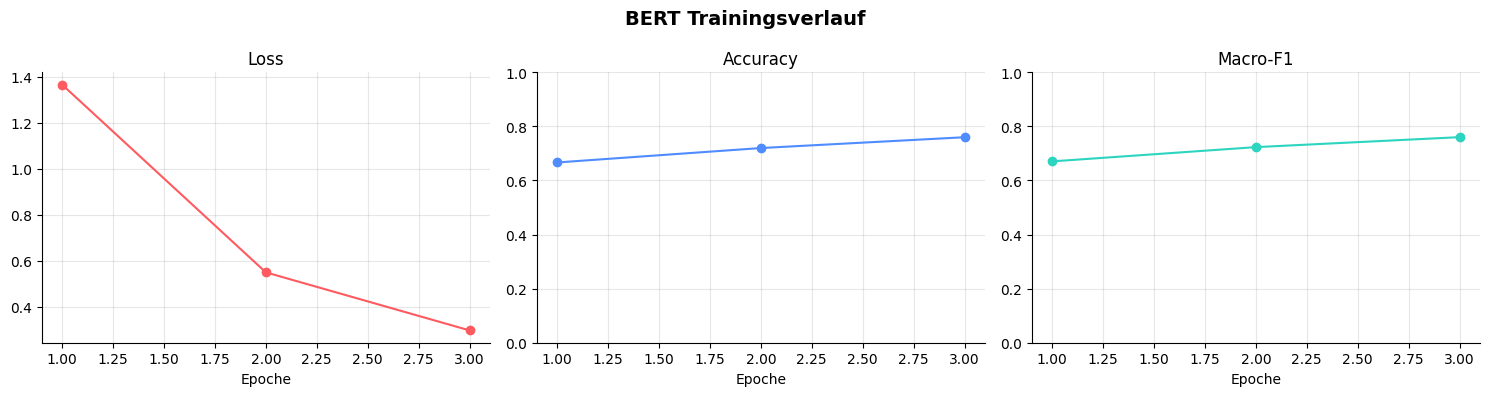

✅ Grafik gespeichert: bert_training_curve.png


In [ ]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('BERT Trainingsverlauf', fontsize=14, fontweight='bold')

axes[0].plot(hist_df['epoch'], hist_df['loss'],     marker='o', color='#ff5a5f')
axes[0].set_title('Loss');     axes[0].set_xlabel('Epoche')

axes[1].plot(hist_df['epoch'], hist_df['accuracy'], marker='o', color='#4f8cff')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoche'); axes[1].set_ylim(0, 1)

axes[2].plot(hist_df['epoch'], hist_df['f1_macro'], marker='o', color='#2dd4bf')
axes[2].set_title('Macro-F1'); axes[2].set_xlabel('Epoche'); axes[2].set_ylim(0, 1)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('bert_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik gespeichert: bert_training_curve.png')

## Zelle 10 – Ergebnisse & Modell herunterladen

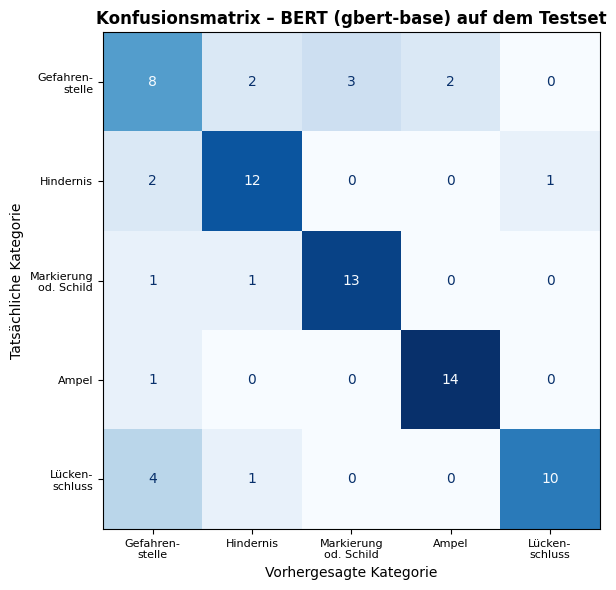

✅ Gespeichert: confusion_matrix_bert.png


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SHORT_LABELS = [
    'Gefahren-\nstelle',
    'Hindernis',
    'Markierung\nod. Schild',
    'Ampel',
    'Lücken-\nschluss',
]

cm   = confusion_matrix(label_names, pred_names, labels=LABELS)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SHORT_LABELS)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Konfusionsmatrix – BERT (gbert-base) auf dem Testset',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Vorhergesagte Kategorie', fontsize=10)
ax.set_ylabel('Tatsächliche Kategorie', fontsize=10)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('confusion_matrix_bert.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gespeichert: confusion_matrix_bert.png')

## Zelle 12 – BERT Labelmenge-Experiment ⬅️ NEU

Trainiert BERT mit 50, 100, 200 und 300 gelabelten Beispielen und vergleicht die Performance.
Ergebnis wird als CSV und Grafik gespeichert.

Trainingspool: 225 | Testset: 75
Starte BERT Labelmenge-Experiment: [50, 100, 150, 225]

[n=50] Training mit 50 Beispielen...


/tmp/ipykernel_1123/3257288746.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_class), random_state=random_state))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: deepset/gbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[n=50] Acc: 0.267  F1: 0.240  (7s)

[n=100] Training mit 100 Beispielen...


...

BertForSequenceClassification LOAD REPORT from: deepset/gbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[n=150] Acc: 0.493  F1: 0.476  (15s)

[n=225] Training mit 225 Beispielen...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: deepset/gbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[n=225] Acc: 0.600  F1: 0.573  (22s)


=== BERT Labelmenge-Experiment Ergebnisse ===
 n_labeled  accuracy  f1_macro
        50  0.266667  0.240251
       100  0.560000  0.564171
       150  0.493333  0.476109
       225  0.600000  0.573058


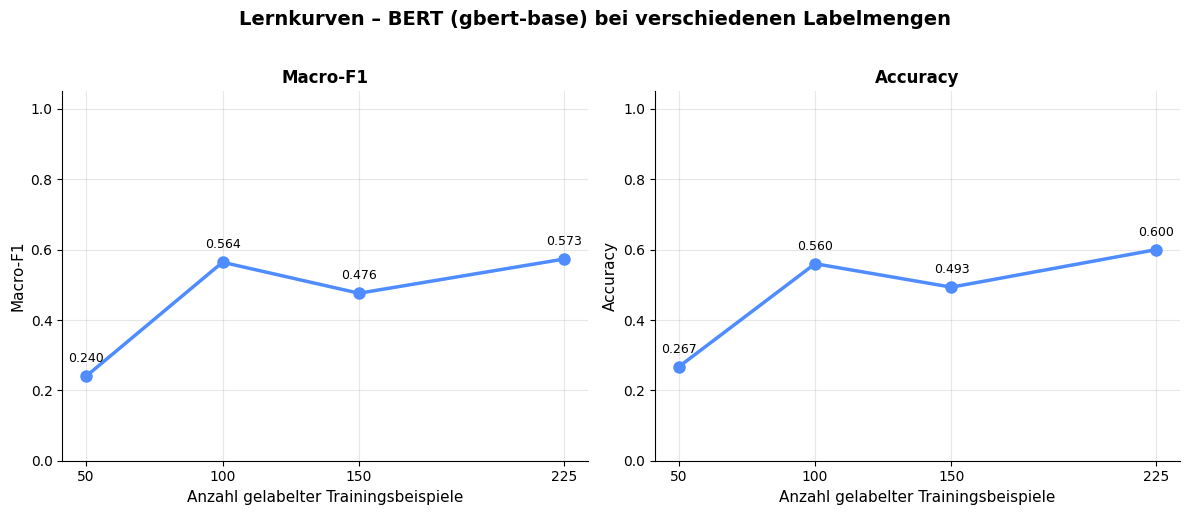

✅ Gespeichert: bert_label_experiment.png und bert_label_experiment.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── BERT Labelmenge-Experiment ────────────────────────────────────────────
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

LABEL_SIZES = [50, 100, 150, 225]
RANDOM_STATE = 42

def subsample(df, n, random_state=42):
    """Stratifiziertes Subsampling aus dem Trainingspool."""
    if n >= len(df):
        return df.copy()
    per_class = max(1, n // len(LABELS))
    return (
        df.groupby('label', group_keys=False)
        .apply(lambda g: g.sample(min(len(g), per_class), random_state=random_state))
        .reset_index(drop=True)
    )

def train_bert_subset(df_labeled, df_test, epochs=3, batch_size=16):
    """Trainiert BERT auf einer Teilmenge und evaluiert auf dem Testset."""
    LABEL2ID_local = {l: i for i, l in enumerate(LABELS)}
    ID2LABEL_local = {i: l for i, l in enumerate(LABELS)}

    X_train = df_labeled['text'].tolist()
    y_train = [LABEL2ID_local[l] for l in df_labeled['label']]
    X_test  = df_test['text'].tolist()
    y_test  = [LABEL2ID_local[l] for l in df_test['label']]

    tok = AutoTokenizer.from_pretrained('deepset/gbert-base')
    mdl = AutoModelForSequenceClassification.from_pretrained(
        'deepset/gbert-base',
        num_labels=len(LABELS),
        id2label=ID2LABEL_local,
        label2id=LABEL2ID_local,
    ).to(device)

    class DS(Dataset):
        def __init__(self, texts, labels):
            self.enc = tok(texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
            self.labels = torch.tensor(labels, dtype=torch.long)
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            item = {k: v[i] for k, v in self.enc.items()}
            item['labels'] = self.labels[i]
            return item

    train_loader = DataLoader(DS(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(DS(X_test,  y_test),  batch_size=batch_size)

    optimizer   = AdamW(mdl.parameters(), lr=2e-5, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    best_f1, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        mdl.train()
        for batch in train_loader:
            optimizer.zero_grad()
            out = mdl(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        mdl.eval()
        preds_all, labels_all = [], []
        with torch.no_grad():
            for batch in test_loader:
                out   = mdl(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
                preds_all.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
                labels_all.extend(batch['labels'].numpy())

        f1m = f1_score(labels_all, preds_all, average='macro', zero_division=0)
        if f1m > best_f1:
            best_f1    = f1m
            best_state = {k: v.clone() for k, v in mdl.state_dict().items()}

    mdl.load_state_dict(best_state)
    mdl.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch in test_loader:
            out   = mdl(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            preds_all.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            labels_all.extend(batch['labels'].numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1m = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    return acc, f1m


# ── Trainingspool laden (nur echte Daten!) ────────────────────────────────
df_pool = pd.read_csv('train_pool.csv')
df_pool['text']  = df_pool['text'].astype(str)
df_pool['label'] = df_pool['label'].astype(str)
df_pool = df_pool[df_pool['label'].isin(LABELS)].reset_index(drop=True)

df_test = pd.read_csv('test.csv')
df_test['text']  = df_test['text'].astype(str)
df_test['label'] = df_test['label'].astype(str)
df_test = df_test[df_test['label'].isin(LABELS)].reset_index(drop=True)

print(f'Trainingspool: {len(df_pool)} | Testset: {len(df_test)}')
print(f'Starte BERT Labelmenge-Experiment: {LABEL_SIZES}\n')

# ── Experiment durchführen ────────────────────────────────────────────────
results = []
for n in LABEL_SIZES:
    df_sub = subsample(df_pool, n)
    print(f'[n={n}] Training mit {len(df_sub)} Beispielen...')
    start = time.time()
    acc, f1m = train_bert_subset(df_sub, df_test)
    elapsed = time.time() - start
    print(f'[n={n}] Acc: {acc:.3f}  F1: {f1m:.3f}  ({elapsed:.0f}s)\n')
    results.append({'n_labeled': n, 'accuracy': acc, 'f1_macro': f1m})

df_results = pd.DataFrame(results)
df_results.to_csv('bert_label_experiment.csv', index=False)
print('\n=== BERT Labelmenge-Experiment Ergebnisse ===')
print(df_results.to_string(index=False))

# ── Lernkurve plotten ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Lernkurven – BERT (gbert-base) bei verschiedenen Labelmengen',
             fontsize=14, fontweight='bold', y=1.02)

for ax, metric, ylabel in zip(axes, ['f1_macro', 'accuracy'], ['Macro-F1', 'Accuracy']):
    ax.plot(df_results['n_labeled'], df_results[metric],
            marker='o', linewidth=2.5, color='#4f8cff', markersize=8)
    for _, row in df_results.iterrows():
        ax.annotate(f"{row[metric]:.3f}",
                    xy=(row['n_labeled'], row[metric]),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=9)
    ax.set_xlabel('Anzahl gelabelter Trainingsbeispiele', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.FixedLocator(LABEL_SIZES))
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('bert_label_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gespeichert: bert_label_experiment.png und bert_label_experiment.csv')

# Download
from google.colab import files
files.download('bert_label_experiment.csv')
files.download('bert_label_experiment.png')


## Zelle 11 – Schnelltest (optional)

Teste das Modell mit eigenen Texten!

In [ ]:
def predict(texts):
    model.eval()
    encodings = tokenizer(
        texts, truncation=True, padding=True,
        max_length=128, return_tensors='pt'
    )
    with torch.no_grad():
        input_ids      = encodings['input_ids'].to(device)
        attention_mask = encodings['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)
        preds   = torch.argmax(probs, dim=1)
    return [(ID2LABEL[preds[i].item()], probs[i][preds[i]].item()) for i in range(len(texts))]


# ── Hier kannst du eigene Texte testen ────────────────────────────────────
test_texts = [
    'Schlagloch auf dem Radweg beim Praterstern',
    'Gefährliche Kreuzung ohne Sicht',
    'Ampel für Radfahrer defekt',
    'Radwegmarkierung fehlt komplett',
    'Radweg endet plötzlich ohne Anschluss',
]

print('Vorhersagen:\n')
results = predict(test_texts)
for text, (label, conf) in zip(test_texts, results):
    print(f'  {conf:.2f}  {label:<25}  {text}')

Vorhersagen:

  0.92  Hindernis                  Schlagloch auf dem Radweg beim Praterstern
  0.92  Gefahrenstelle             Gefährliche Kreuzung ohne Sicht
  0.95  Ampel                      Ampel für Radfahrer defekt
  0.94  Markierung oder Schild     Radwegmarkierung fehlt komplett
  0.66  Lückenschluss              Radweg endet plötzlich ohne Anschluss
